In [262]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo
import ast




In [302]:
# --- User toggle ---
Cristina = True
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"
    base_dir = '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output'
    
elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"
    base_dir = '/lustre/lrspec/metrics/results'

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Cristina's local MacBook setup


In [306]:
#this happens twice because idk why but it only works like that
#...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

metric_filename = "local_MDwarfFlares_metric"
s_u = "shared_utils"

# --- Reload metric module ---
if metric_filename in sys.modules:
    del sys.modules[metric_filename]
metric = __import__(metric_filename)
importlib.reload(metric)

# --- Reload shared_utils module ---
if s_u in sys.modules:
    del sys.modules[s_u]
shared_utils = __import__(s_u)
importlib.reload(shared_utils)

print(f"[INFO] Loaded metric module: {metric_filename}")
print(f"[INFO] Loaded shared_utils module")




/opt/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric local_MDwarfFlares_metric.Base_Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/opt/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric local_MDwarfFlares_metric.Detect_Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/opt/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric local_MDwarfFlares_metric.MDwarfFlareSilverMetric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/opt/anaconda3/envs/rubin_sim_223/lib/python

[INFO] Loaded metric module: local_MDwarfFlares_metric
[INFO] Loaded shared_utils module


In [308]:
#metric configurations
use_kcorrect=False
k_correct_type = None
k_correct_arg = None
testname=None  
#use this to add text to the filename
#if you're testing template or population variables other than the below variables

testname_metric_only=None 
num_lightcurves=1000

#use this to add text to the filename for the observation record df only (does not change pop/template filenames)
#so for anything you're changing that's only about the detection criteria

#control whether we generate new files - 
#new files will still generate if these are false and it can't find a file with the correct parameters
#so recommend leaving it on false
generate_new_templates = True 
generate_new_pop = True
make_debug_plots = True #toggle whether or not the pop generation makes plots

#population variables
rate_density = 76*10**9/((4/3)*np.pi*(.03**3-0.0000013**3)) /1000000
#dividing by 1000000 so that we can actually use these numbers

#the milky way contains 100–400 billion stars
#76% of main sequence stars are m dwarfs
#i dont know how many non-main-sequence stars there are so...
#let's say there are 100 billion main sequence stars
#so 76 billion m dwarfs
#rate density calculation: 76*10*9 /((4/3)*np.pi*(.03**3-0.0000013**3))
#....that's the number of m dwarfs. it's supposed to be per year but it's not right now
#how many flares does a star have per year?

# apply None for non-use case 
z_min, z_max = None, None #.00226, .3
d_min, d_max = 0.0000013, .03 # #proxima cen is an m-dwarf apparently at 1.3 pc
#the milky way is 30 kpc across and the sun is 8kpc from the center
#let's just use 30 kpc because we don't have a way to weight it right now


#other
gal_lat_cut = 30 #latitude cut, for Galactic phenomena
use_extinction = True
t_start = 1 #start time in days
t_end = 3652

# Whether to remove Metric_temp_* folders after running
clean_temp = True  # <- NEW toggle

#cadence variables
cadences = ['four_roll_v4.3.1_10yrs'] #'baseline_v4.3.1_10yrs','noroll_v3.6_10yrs']
#cadences = ['four_roll_v5.0.0_10yrs']#, 'baseline_v5.0.0_10yrs','noroll_v3.6_10yrs','baseline_v3.6_10yrs']

ignore_triples = False #turn this to true to ignore triples

# Standardized output paths for this science case
# paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
paths = shared_utils.build_filenames(testname=testname,
                        testname_metric_only=testname_metric_only,
                        science_case="MDwarfFlares", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, summary_filename = paths

MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None


In [310]:
#load and/or generate light curves
shared_lc_model = shared_utils.load_or_generate_templates(metric.LC,
    templates_file=templates_file,
    generate_new=generate_new_templates
)

[INFO] Generating 1000 light curve templates.
Saved synthetic light curve templates to /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_templates.pkl
Loaded flare templates from /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_templates.pkl


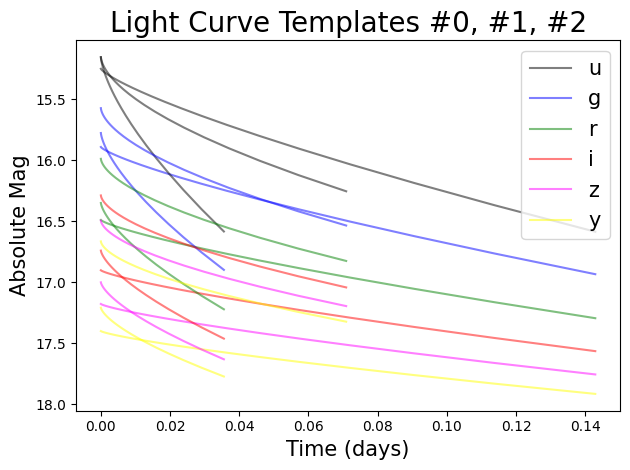

In [313]:
#plot light curves from pkl file if desired
ylim = None
use_log_time = False
plot_overlap = True
shared_utils.plot_template_lcs(templates_file, num=3, use_log_time = use_log_time,plot_overlap=plot_overlap,ylim=ylim)

[INFO] Generating population and saving to /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_population.pkl
Simulated 761806 events using rate_density = 6.7e+08
Len ra before masking:  761806
b:  [ 31.42221553 -69.77132472 -42.30667511 ... -79.75993699  37.99081593
 -13.62015784]
len mask, num true in mask:  761806 380787
len ra after masking:  380787


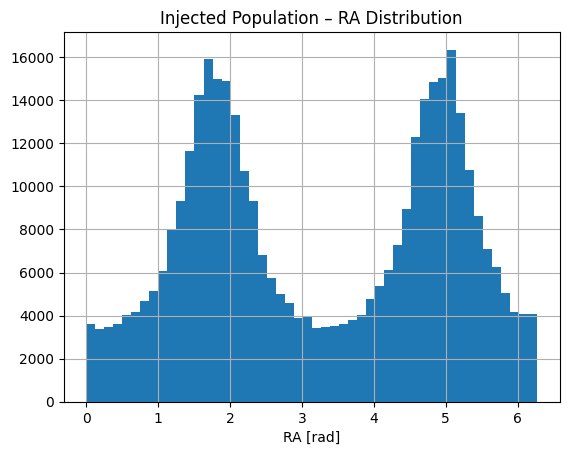

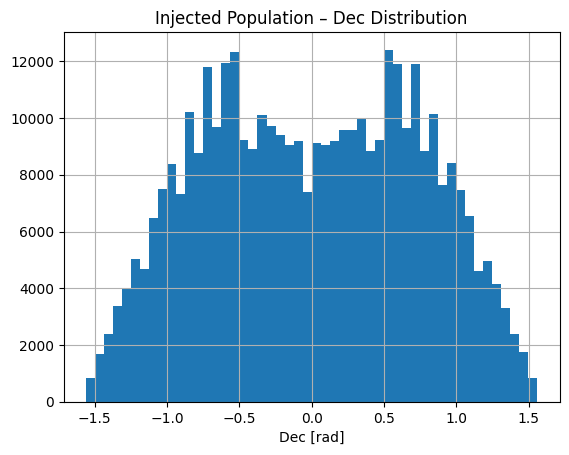

initial peak times:  [ 976.00281234 1791.43521857  647.96523879 ... 2433.51272618 2025.03025395
 1440.04265002]
gal_lat_cut is none


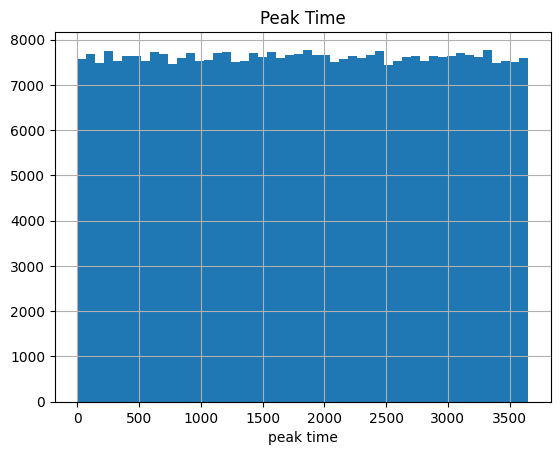

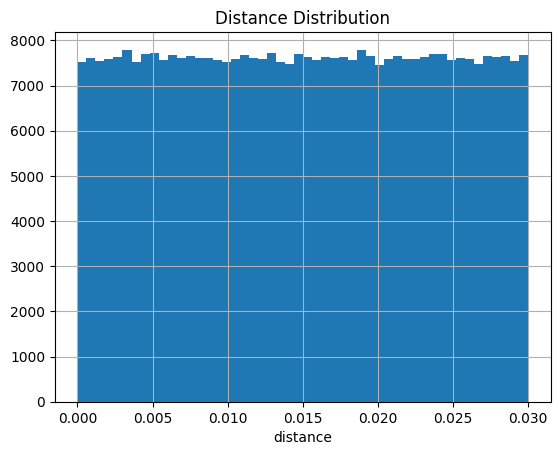

[DEBUG] coords.dec[:5]: [  7.18075578 -45.78396716 -23.31795707  36.42357364 -27.95318688] deg
[DEBUG] coords.dec.unit: deg


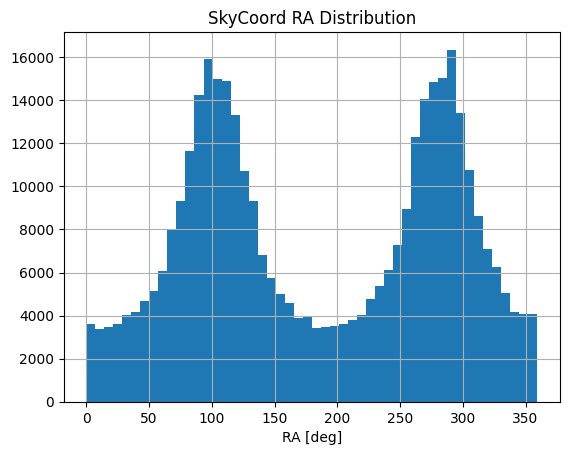

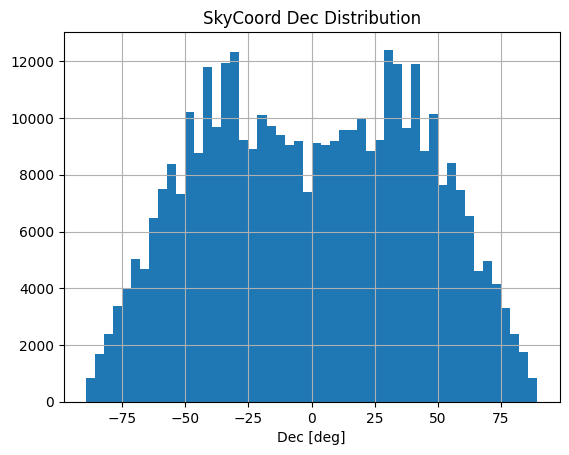

[INFO] Saved atomically to /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_population.pkl
DEBUG: type(peak_times) = <class 'numpy.ndarray'>
DEBUG: shape(peak_times) = (380787,)


In [315]:
# Load or generate population slicer
slicer = shared_utils.load_or_generate_population(use_extinction=use_extinction,
    lc_model=shared_lc_model,
    t_start=t_start,
    t_end=t_end,
    d_min=d_min,
    d_max=d_max,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    num_lightcurves=num_lightcurves, #technically should read this from the file
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots
)


## All 10 years

In [317]:
importlib.reload(shared_utils)

<module 'shared_utils' from '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/shared_utils.py'>


--- Running four_roll_v4.3.1_10yrs ---

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 204
mag_obs         | type: <class 'list'> | length: 204
snr_obs         | type: <class 'list'> | length: 204
filter          | type: <class 'list'> | length: 204
diag_sample_mjd | type: <class 'list'> | length: 4
diag_sample_mag | type: <class 'list'> | length: 4
diag_sample_snr | type: <class 'list'> | length: 4
diag_sample_filter | type: <class 'list'> | length: 4
per_filter_min_mag | type: <class 'dict'> | length: 6
max_flux_change_sigma | type: <class 'dict'> | length: 6
any_flux_change_gt3 | type: <class 'bool'> | value: False
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
fade_time_days  | type: <class 'float'> | value: nan
sid_duplicate   | type: <class 'numpy.int64'> | value: 0
file_indx       | type: <class 'numpy.int64'> | value: 364
ra              | type: <class 'numpy.float64'> 

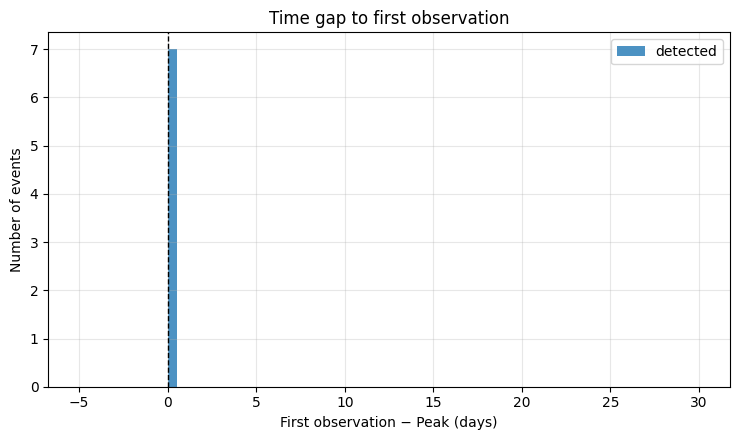

[diag] per_filter_min_mag mostly empty — recomputing from lists.


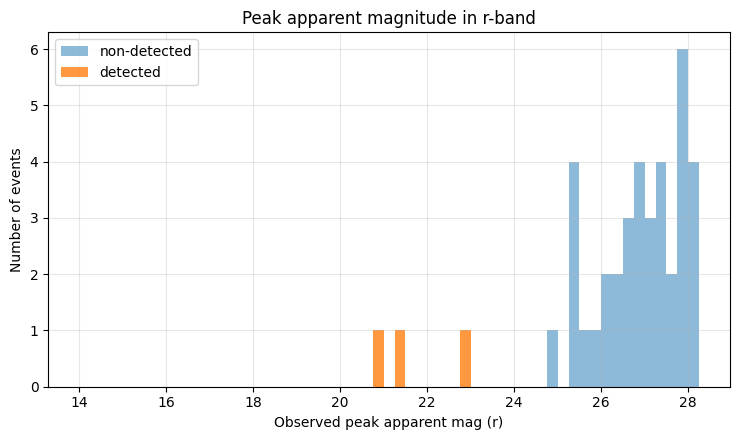

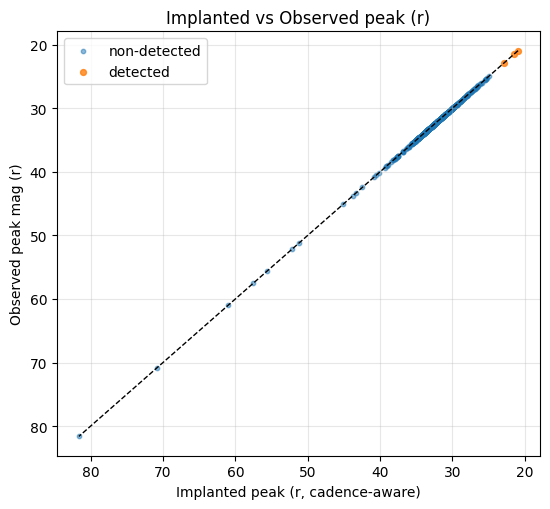

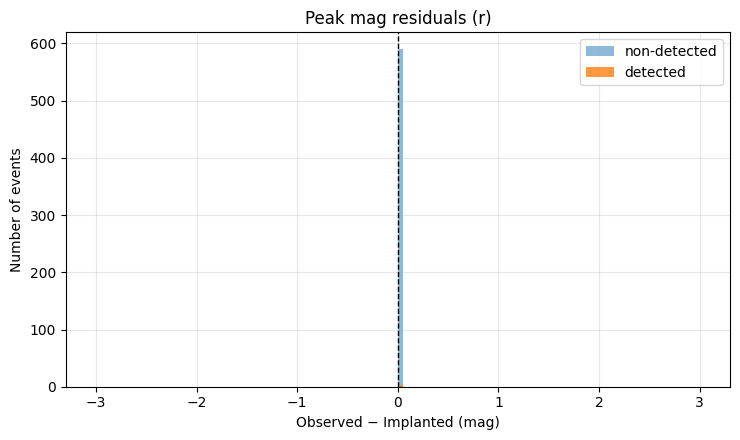

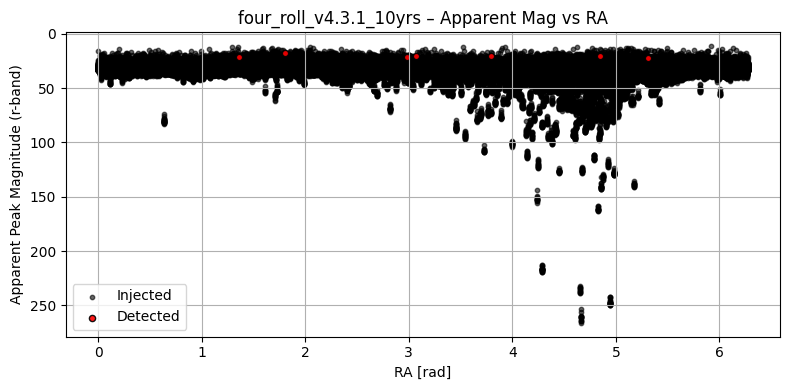

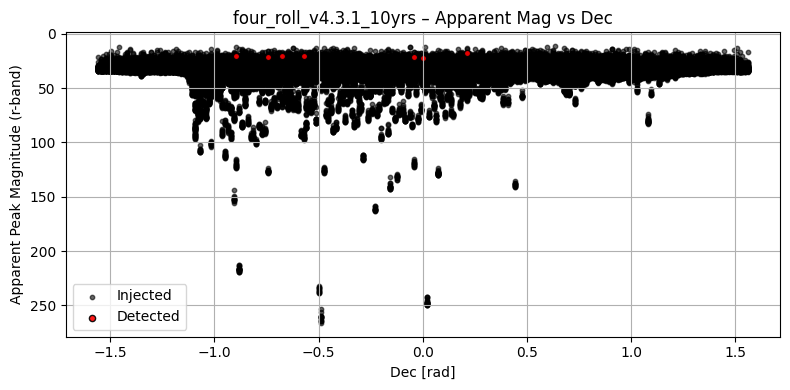

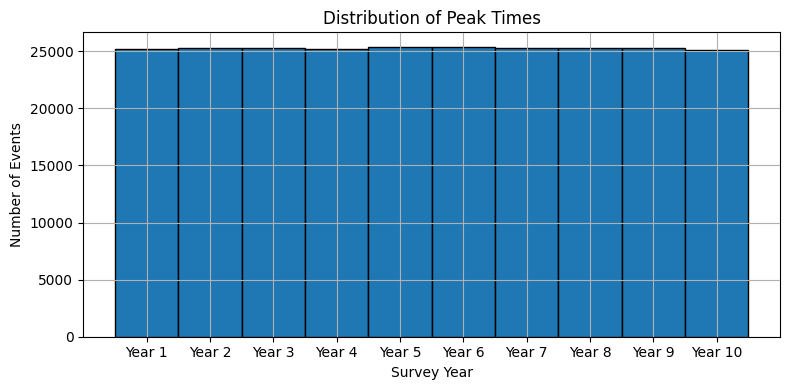

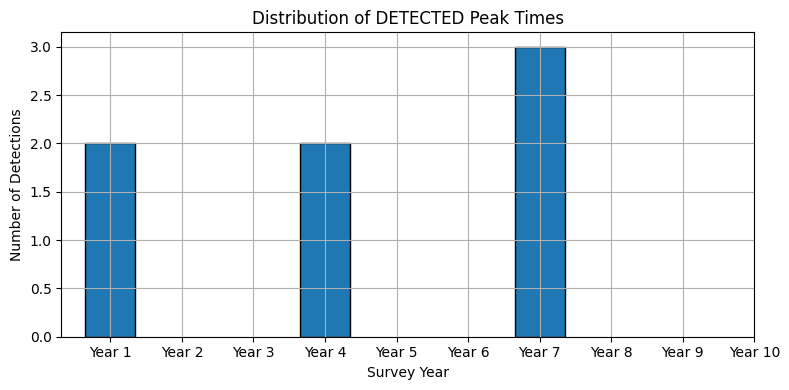

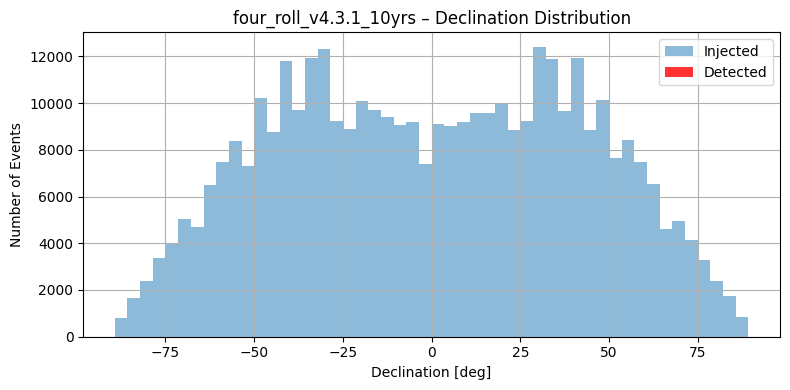

[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/Metric_temp_four_roll_v4.3.1_10yrs


In [318]:
#run detection metric
df_obs = shared_utils.run_detect(metric, 
                                 slicer, 
                                 cadences, 
                                 shared_lc_model, 
                                 db_dir, storage_dir, 
                                 df_file, 
                                 ignore_triples=ignore_triples, 
                                 debug=True, plot=True, 
                                 clean_temp=clean_temp,
                                 use_kcorrect=use_kcorrect,
                                 k_correct_type=None,
                                 k_correct_arg=None,
                                 use_extinction=use_extinction)

In [319]:



cols = ["sid",
        "injected_peak_ebv_mag_r",
        "injected_peak_ebv_mag_r_cadence",
        "eval_peak_mag"]
print(df_obs[cols].head())

print("Residuals vs cadence-aware (should ~0):",
      np.nanmedian(df_obs["eval_peak_mag"] - df_obs["injected_peak_ebv_mag_r_cadence"]))

print("Cadence penalty (cadence − global):",
      np.nanmedian(df_obs["injected_peak_ebv_mag_r_cadence"] - df_obs["injected_peak_ebv_mag_r"]))


   sid  injected_peak_ebv_mag_r  injected_peak_ebv_mag_r_cadence  \
0    0                33.283124                              NaN   
1    1                30.145389                              NaN   
2    2                34.265142                              NaN   
3    4                27.798796                              NaN   
4    5                34.182891                              NaN   

   eval_peak_mag  
0            NaN  
1            NaN  
2            NaN  
3            NaN  
4            NaN  
Residuals vs cadence-aware (should ~0): 0.0
Cadence penalty (cadence − global): 0.48632856095298393


In [320]:

#choose what to run in run_multi_metrics
# we can remove historical if we want
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=[ 'detect','silver','gold'], use_extinction=use_extinction)#, use_kcorrect=use_kcorrect, k_correct_type=None, k_correct_arg=None)


# Apply consistent diagnostics knobs
for m in multi_metrics:
    m.diag_store = True
    m.diag_sample_rate = 0.01
    m.diag_per_event_cap = 30
    m.diag_min_snr = 3
    m.diag_max_mag = None




--- Running four_roll_v4.3.1_10yrs ---
(3,)
[<local_MDwarfFlares_metric.Detect_Metric object at 0x721ebc650>, <local_MDwarfFlares_metric.MDwarfFlareSilverMetric object at 0x32b9d9490>, <local_MDwarfFlares_metric.MDwarfFlareGoldMetric object at 0xf82b85590>]
                                      Sum                     run  \
four_roll_v4.3.1_10yrs_Detect_Metric  7.0  four_roll_v4.3.1_10yrs   

                                      n_events_full_sky  
four_roll_v4.3.1_10yrs_Detect_Metric             380787  


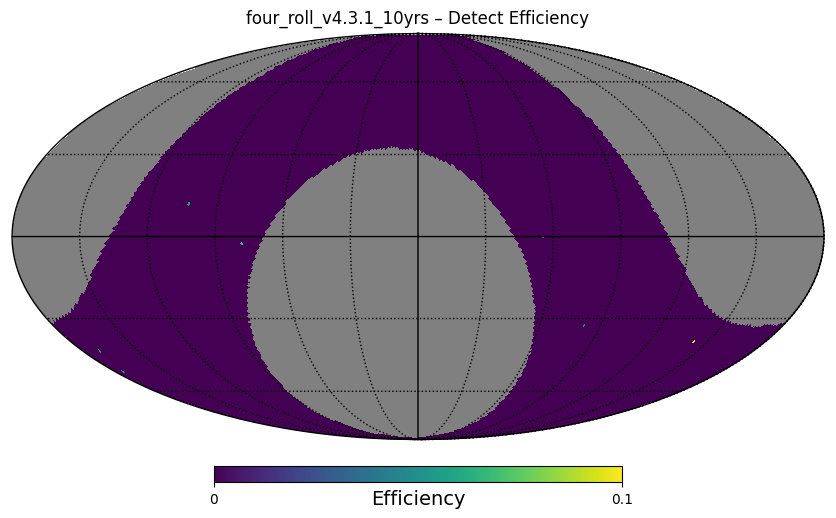

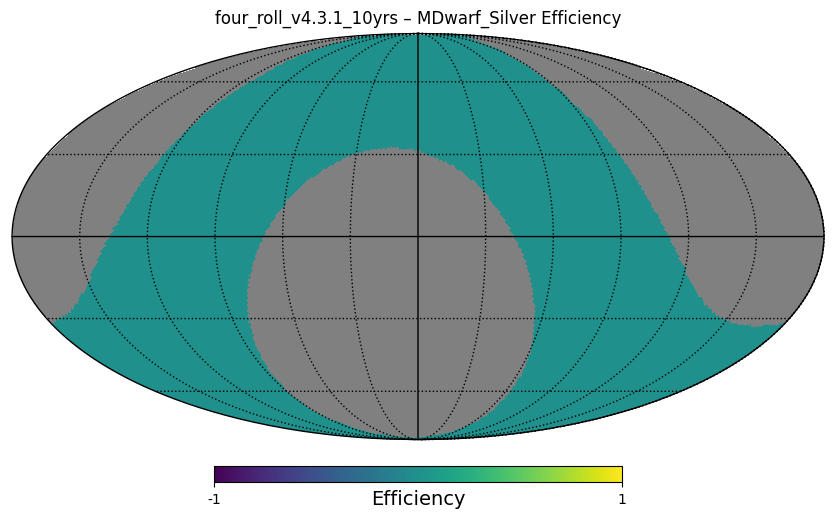

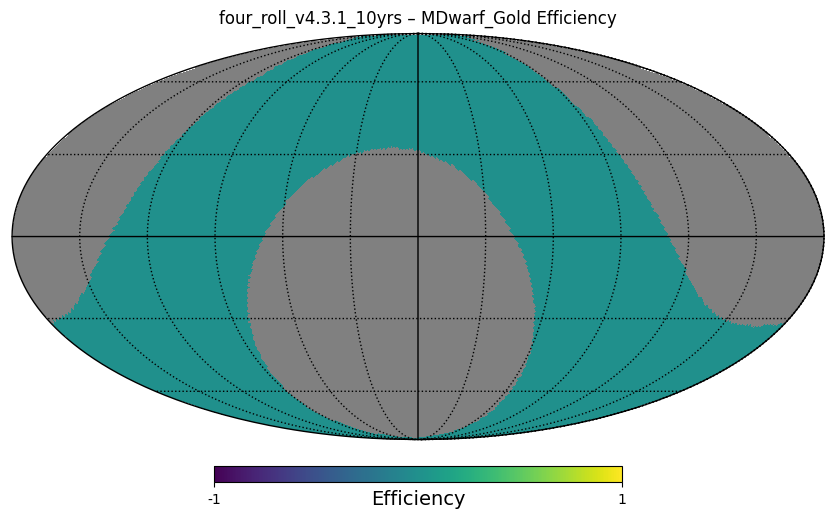

[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/Metric_temp_four_roll_v4.3.1_10yrs
saved summary to  /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_None_multi_summary.csv


In [321]:
summary_df_2 = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)


--- Running four_roll_v4.3.1_10yrs ---
(3,)
[<local_MDwarfFlares_metric.Detect_Metric object at 0x721ebc650>, <local_MDwarfFlares_metric.MDwarfFlareSilverMetric object at 0x32b9d9490>, <local_MDwarfFlares_metric.MDwarfFlareGoldMetric object at 0xf82b85590>]
                                      Sum                     run  \
four_roll_v4.3.1_10yrs_Detect_Metric  7.0  four_roll_v4.3.1_10yrs   

                                      n_events_full_sky  
four_roll_v4.3.1_10yrs_Detect_Metric             380787  


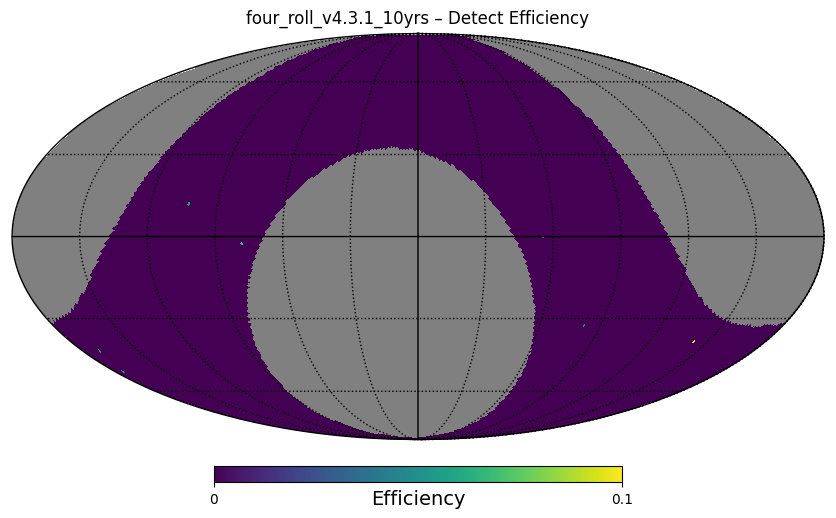

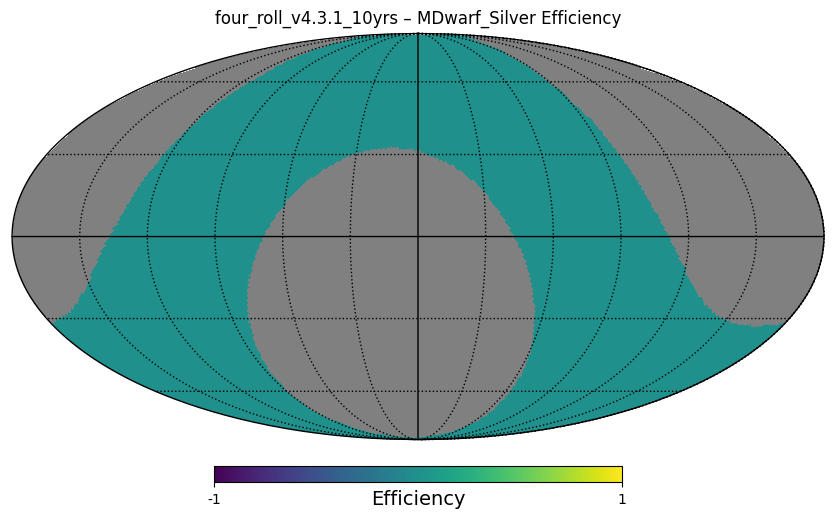

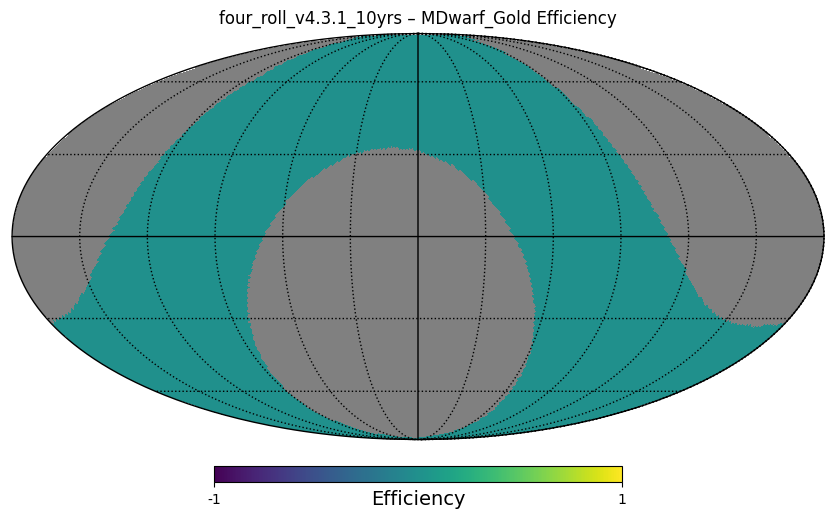

[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/Metric_temp_four_roll_v4.3.1_10yrs
saved summary to  /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_None_multi_summary.csv


In [322]:
summary_df_1 = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [323]:
summary_df_1

,Sum,run,n_events_full_sky
four_roll_v4.3.1_10yrs_Detect_Metric,7.0,four_roll_v4.3.1_10yrs,380787
four_roll_v4.3.1_10yrs_MDwarfFlareSilverMetric,0.0,four_roll_v4.3.1_10yrs,380787
four_roll_v4.3.1_10yrs_MDwarfFlareGoldMetric,0.0,four_roll_v4.3.1_10yrs,380787


In [325]:
import pickle
with open(pop_file, 'rb') as f:
    sp = pickle.load(f)
missing = [f'peak_app_mag_ebv_{f}' for f in ('u','g','r','i','z','y') if f'peak_app_mag_ebv_{f}' not in sp]
print("Missing peak columns:", missing or "None — all present")


Missing peak columns: None — all present


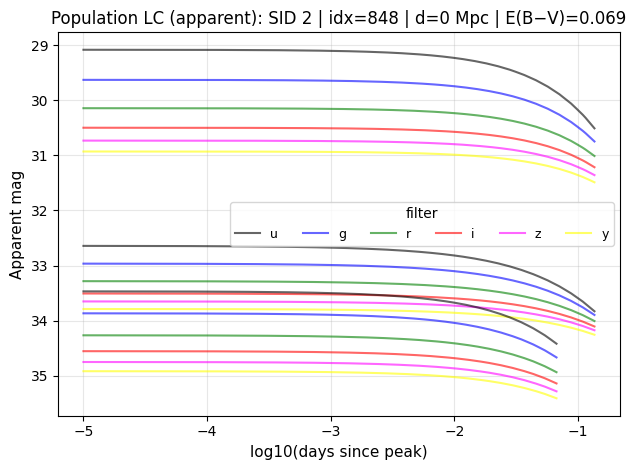

In [327]:
shared_utils.plot_population_lcs(
    pop_file=pop_file,
    lc_model=shared_lc_model,   # or pass templates_file=templates_file
    fast_peaks=False,
    use_kcorrect=use_kcorrect,
    k_correct_type=k_correct_type,
    k_correct_arg=k_correct_arg,
    num=3,
    days_before=0.0,            # see note below
    days_after=100.0,
    use_log_time=True,
    overlap=True
)
